# Gabarito — Perpendicularidade

Este notebook traz a resolução comentada dos exercícios de [`0407a_perpendicularidade.ipynb`](0407a_perpendicularidade.ipynb).

⚠️ **Antes de olhar aqui:** tente resolver os exercícios sozinho no notebook original e use as células de verificação (`assert`) para conferir sua resposta. Volte a este gabarito só depois de tentar — ou se travar de verdade em algum passo.

In [1]:
# Imports necessários para os exercícios abaixo.
import math

import matplotlib.pyplot as plt
import numpy as np
from matplotlib.patches import Polygon

# Paleta de cores Nord
NORD_FUNDO = "#2E3440"
NORD_LINHA = "#4C566A"
NORD_TEXTO = "#ECEFF4"
NORD_TEXTO_SEC = "#D8DEE9"
COR_PONTO = "#88C0D0"
COR_DESTAQUE = "#A3BE8C"
COR_ALERTA = "#BF616A"
COR_SECUNDARIA = "#81A1C1"
COR_AVISO = "#EBCB8B"


# Ferramentas do notebook principal (reconstruídas aqui).
def direcao(angulo_graus: float) -> np.ndarray:
    """Vetor de tamanho 1 apontando na direção dada, em graus, a partir da horizontal."""
    rad = math.radians(angulo_graus)
    return np.array([math.cos(rad), math.sin(rad)])


def direcao_de(origem, destino) -> float:
    """Direção, em graus, em que `destino` está quando visto de `origem`."""
    return math.degrees(math.atan2(destino[1] - origem[1], destino[0] - origem[0]))


def medir_angulo(vertice, P, Q) -> float:
    """Transferidor digital: medida, em graus, do ângulo com vértice em `vertice` entre P e Q."""
    u = np.subtract(P, vertice)
    v = np.subtract(Q, vertice)
    cosseno = np.dot(u, v) / (np.linalg.norm(u) * np.linalg.norm(v))
    return math.degrees(math.acos(np.clip(cosseno, -1, 1)))


def cruzamento(P, inclinacao_1: float, Q, inclinacao_2: float):
    """Ponto em que a reta por P (inclinacao_1) cruza a reta por Q (inclinacao_2); None se paralelas."""
    matriz = np.column_stack([direcao(inclinacao_1), -direcao(inclinacao_2)])
    if abs(np.linalg.det(matriz)) < 1e-12:
        return None
    t, _ = np.linalg.solve(matriz, np.subtract(Q, P))
    return np.array(P, dtype=float) + t * direcao(inclinacao_1)


def preparar_eixo(ax, pontos, margem: float = 0.8) -> None:
    """Eixo no estilo Nord, sem grade e sem números, com escala igual, enquadrando os `pontos`."""
    ax.set_facecolor(NORD_FUNDO)
    for spine in ax.spines.values():
        spine.set_color(NORD_LINHA)
    xs, ys = [p[0] for p in pontos], [p[1] for p in pontos]
    ax.set_xlim(min(xs) - margem, max(xs) + margem)
    ax.set_ylim(min(ys) - margem, max(ys) + margem)
    ax.set_aspect("equal")
    ax.set_xticks([])
    ax.set_yticks([])


def desenhar_reta(ax, ponto, inclinacao: float, cor: str = COR_SECUNDARIA, largura: float = 2.5) -> None:
    """Desenha a reta que passa por `ponto` com a inclinação dada (em graus)."""
    p, d = np.array(ponto, dtype=float), direcao(inclinacao)
    ax.plot(*zip(p - 100 * d, p + 100 * d), color=cor, lw=largura)


def marcar_angulo_reto(ax, vertice, p, q, tamanho: float = 0.3, cor: str = COR_DESTAQUE) -> None:
    """Quadradinho de ângulo reto no `vertice`, entre as semirretas que passam por p e por q."""
    v = np.array(vertice, dtype=float)
    u = np.subtract(p, v) / np.linalg.norm(np.subtract(p, v))
    w = np.subtract(q, v) / np.linalg.norm(np.subtract(q, v))
    canto = [v, v + tamanho * u, v + tamanho * (u + w), v + tamanho * w]
    ax.add_patch(Polygon(canto, closed=True, facecolor=cor, alpha=0.35, edgecolor=cor, lw=2, zorder=4))

## Básico

**Exercício 1.** Decidir, a partir das inclinações, se duas retas são perpendiculares.

In [2]:
def sao_perpendiculares_ex1(inclinacao_1: float, inclinacao_2: float) -> bool:
    """True se as retas com essas inclinações são perpendiculares."""
    # O ângulo entre as retas sai da diferença das inclinações. O "% 180" joga essa diferença
    # para o intervalo [0, 180): assim, −90° e 270° viram 90°, e 180° vira 0° (mesma direção).
    diferenca = (inclinacao_2 - inclinacao_1) % 180
    # Comparamos com math.isclose porque contas com decimais podem deixar sobras como 89.99999999.
    return math.isclose(diferenca, 90, abs_tol=1e-9)


for incl_1, incl_2 in [(30, 120), (30, 100), (45, -45), (10, 280), (20, 200)]:
    print(f"{incl_1:>4}° e {incl_2:>4}°: diferença % 180 = {(incl_2 - incl_1) % 180:>5g}°  ->  "
          f"{sao_perpendiculares_ex1(incl_1, incl_2)}")

  30° e  120°: diferença % 180 =    90°  ->  True
  30° e  100°: diferença % 180 =    70°  ->  False
  45° e  -45°: diferença % 180 =    90°  ->  True
  10° e  280°: diferença % 180 =    90°  ->  True
  20° e  200°: diferença % 180 =     0°  ->  False


**Exercício 2.** Construir a perpendicular a $r$ (por $A = (0, 1)$, inclinação 30°) passando por $P = (2, 5)$.

inclinação da perpendicular: 120°
P' = (3.2321, 2.8660)
conferindo o ângulo reto: PP'A = 90.0000°


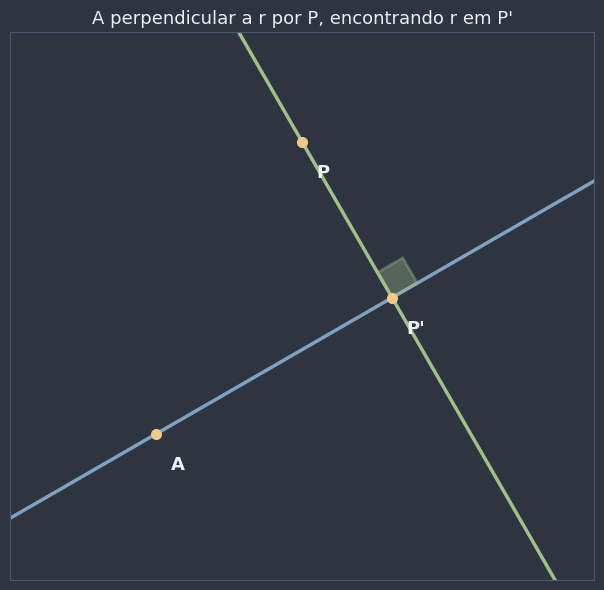

In [3]:
A_ex2, P_ex2, inclinacao_r_ex2 = np.array([0.0, 1.0]), np.array([2.0, 5.0]), 30

# (a) A perpendicular tem a inclinação de r girada 90°: 30° + 90° = 120°
#     (−60° também serviria: é a mesma direção, "a menos de 180°").
inclinacao_ex2 = inclinacao_r_ex2 + 90

# (b) P' é o ponto em que a perpendicular (por P, 120°) cruza r (por A, 30°).
pe_ex2 = cruzamento(P_ex2, inclinacao_ex2, A_ex2, inclinacao_r_ex2)
print(f"inclinação da perpendicular: {inclinacao_ex2}°")
print(f"P' = ({pe_ex2[0]:.4f}, {pe_ex2[1]:.4f})")
print(f"conferindo o ângulo reto: PP'A = {medir_angulo(pe_ex2, P_ex2, A_ex2):.4f}°")

# Desenho da construção
fig, ax = plt.subplots(figsize=(8, 6))
fig.patch.set_facecolor(NORD_FUNDO)
preparar_eixo(ax, [(-2, -1), (6, 6.5)], margem=0)
desenhar_reta(ax, A_ex2, inclinacao_r_ex2, cor=COR_SECUNDARIA)
desenhar_reta(ax, P_ex2, inclinacao_ex2, cor=COR_DESTAQUE)
marcar_angulo_reto(ax, pe_ex2, pe_ex2 + direcao(inclinacao_r_ex2), P_ex2, tamanho=0.4)
for ponto, nome in ((A_ex2, "A"), (P_ex2, "P"), (pe_ex2, "P'")):
    ax.plot(*ponto, "o", color=COR_AVISO, markersize=7, zorder=5)
    ax.text(ponto[0] + 0.2, ponto[1] - 0.5, nome, color=NORD_TEXTO, fontsize=13, fontweight="bold")
ax.set_title("A perpendicular a r por P, encontrando r em P'", color=NORD_TEXTO, fontsize=13)
plt.tight_layout()
plt.show()

## Intermediário

**Exercício 3.** Projeção ortogonal e distância de um ponto à reta dada por dois pontos.

In [4]:
def projecao_ex3(P, A, B) -> np.ndarray:
    """Projeção ortogonal de P sobre a reta que passa por A e B."""
    inclinacao_r = direcao_de(A, B)                # a inclinação de r sai dos dois pontos
    inclinacao_perpendicular = inclinacao_r + 90   # a perpendicular gira 90°
    # P' é o cruzamento da perpendicular por P com r (por A). Se P estiver em r, o cruzamento é o próprio P.
    return cruzamento(P, inclinacao_perpendicular, A, inclinacao_r)


def distancia_ex3(P, A, B) -> float:
    """Distância de P à reta AB: a medida de PP'."""
    return math.dist(P, projecao_ex3(P, A, B))


casos = [((1, 5), (-2, -1), (6, 3)), ((3, -2), (0, 1), (4, 1)), ((0, 0), (0, 4), (4, 0)),
         ((5, 2), (1, -3), (1, 7)), ((4, 4), (0, 0), (1, 1))]
for P, A, B in casos:
    P, A, B = (np.array(p, dtype=float) for p in (P, A, B))
    proj = projecao_ex3(P, A, B)
    print(f"P = ({P[0]:g}, {P[1]:g}), reta por ({A[0]:g}, {A[1]:g}) e ({B[0]:g}, {B[1]:g}):  "
          f"P' = ({proj[0]:.3f}, {proj[1]:.3f}),  "
          f"dist = {distancia_ex3(P, A, B):.4f}")
# Repare no último caso: P = (4, 4) está sobre a reta y = x, então P' = P e a distância é 0.

P = (1, 5), reta por (-2, -1) e (6, 3):  P' = (2.800, 1.400),  dist = 4.0249
P = (3, -2), reta por (0, 1) e (4, 1):  P' = (3.000, 1.000),  dist = 3.0000
P = (0, 0), reta por (0, 4) e (4, 0):  P' = (2.000, 2.000),  dist = 2.8284
P = (5, 2), reta por (1, -3) e (1, 7):  P' = (1.000, 2.000),  dist = 4.0000
P = (4, 4), reta por (0, 0) e (1, 1):  P' = (4.000, 4.000),  dist = 0.0000


**Exercício 4.** A mediatriz de $\overline{AB}$, com $A = (1, 2)$ e $B = (7, 6)$, testada em 5 pontos sorteados.

In [5]:
A_ex4, B_ex4 = np.array([1.0, 2.0]), np.array([7.0, 6.0])

# (a) Ponto médio: a média das coordenadas.
M_ex4 = (A_ex4 + B_ex4) / 2  # (4, 4)

# (b) AB tem inclinação de cerca de 33,69°; a mediatriz é perpendicular: mais 90°.
inclinacao_ex4 = direcao_de(A_ex4, B_ex4) + 90

# (c) Cada valor de t dá um ponto diferente da mediatriz: andamos t unidades a partir de M,
#     na direção dela. (A semente só serve para este gabarito sortear sempre os mesmos t.)
np.random.seed(7)
valores_t = np.random.uniform(-10, 10, 5)
pontos_ex4 = [M_ex4 + t * direcao(inclinacao_ex4) for t in valores_t]

# (d) Para cada ponto, a diferença entre as distâncias até A e até B.
diferencas_ex4 = [abs(math.dist(P, A_ex4) - math.dist(P, B_ex4)) for P in pontos_ex4]

print(f"M = {M_ex4}, inclinação da mediatriz = {inclinacao_ex4:.2f}°\n")
for t, P, dif in zip(valores_t, pontos_ex4, diferencas_ex4):
    print(f"t = {t:6.2f}:  P = ({P[0]:6.2f}, {P[1]:6.2f}),  PA = {math.dist(P, A_ex4):.6f},  "
          f"PB = {math.dist(P, B_ex4):.6f},  |PA − PB| = {dif:.1e}")

M = [4. 4.], inclinação da mediatriz = 123.69°

t =  -8.47:  P = (  8.70,  -3.05),  PA = 9.209010,  PB = 9.209010,  |PA − PB| = 1.8e-15
t =   5.60:  P = (  0.89,   8.66),  PA = 6.658965,  PB = 6.658965,  |PA − PB| = 1.8e-15
t =  -1.23:  P = (  4.68,   2.98),  PA = 3.810167,  PB = 3.810167,  |PA − PB| = 4.4e-16
t =   4.47:  P = (  1.52,   7.72),  PA = 5.742358,  PB = 5.742358,  |PA − PB| = 8.9e-16
t =   9.56:  P = ( -1.30,  11.95),  PA = 10.217122,  PB = 10.217122,  |PA − PB| = 1.8e-15


## Desafio

**Exercício 5.** O ponto equidistante de três bairros, no cruzamento de duas mediatrizes.

In [6]:
A_ex5, B_ex5, C_ex5 = np.array([0.0, 0.0]), np.array([8.0, 0.0]), np.array([2.0, 6.0])

# (a) Mediatriz de AB: passa por M_AB = (4, 0); AB é horizontal (0°), então a mediatriz tem 90°.
#     Mediatriz de AC: passa por M_AC = (1, 3); AC tem cerca de 71,57°, então a mediatriz tem 161,57°.
M_AB, M_AC = (A_ex5 + B_ex5) / 2, (A_ex5 + C_ex5) / 2
inclinacao_AB_ex5 = direcao_de(A_ex5, B_ex5) + 90
inclinacao_AC_ex5 = direcao_de(A_ex5, C_ex5) + 90

# (b) Um ponto da mediatriz de AB está à mesma distância de A e de B; um ponto da mediatriz de AC,
#     à mesma distância de A e de C. O cruzamento está nas duas: equidistante de A, B e C.
escola_ex5 = cruzamento(M_AB, inclinacao_AB_ex5, M_AC, inclinacao_AC_ex5)

# (c) As três distâncias (todas iguais a √20 ≈ 4,47 km).
distancias_ex5 = (math.dist(escola_ex5, A_ex5), math.dist(escola_ex5, B_ex5), math.dist(escola_ex5, C_ex5))

# (d) Se a escola está à mesma distância de B e de C, pela "volta" do teorema da seção 4
#     ela está na mediatriz de BC. As três mediatrizes passam pelo mesmo ponto!
na_mediatriz_BC_ex5 = math.isclose(distancias_ex5[1], distancias_ex5[2])

print(f"escola = ({escola_ex5[0]:.4f}, {escola_ex5[1]:.4f})")
print(f"distâncias até A, B e C: {', '.join(f'{x:.4f}' for x in distancias_ex5)}  (√20 = {math.sqrt(20):.4f})")
print(f"está na mediatriz de BC? {na_mediatriz_BC_ex5}")
# Esse ponto é o CIRCUNCENTRO do triângulo ABC, assunto de Pontos Notáveis do Triângulo.

escola = (4.0000, 2.0000)
distâncias até A, B e C: 4.4721, 4.4721, 4.4721  (√20 = 4.4721)
está na mediatriz de BC? True


**Exercício 6.** O refletido de $P = (1, 5)$ em relação à reta $y = x$, usando a projeção ortogonal.

In [7]:
O_ex6, P_ex6, inclinacao_r_ex6 = np.array([0.0, 0.0]), np.array([1.0, 5.0]), 45

# (a) Projeção ortogonal: a perpendicular a r por P (45° + 90° = 135°) cruzando r.
pe_ex6 = cruzamento(P_ex6, inclinacao_r_ex6 + 90, O_ex6, inclinacao_r_ex6)  # (3, 3)

# (b) P' = (P + P'') / 2  =>  2·P' = P + P''  =>  P'' = 2·P' − P.
refletido_ex6 = 2 * pe_ex6 - P_ex6  # (5, 1): as coordenadas de P trocadas de lugar!

# (c) As duas distâncias até r. A projeção de P'' sobre r também é P' (P, P' e P'' estão na mesma
#     perpendicular), então as duas distâncias são PP' e P''P', que são iguais (P' é ponto médio).
dist_P_ex6 = math.dist(P_ex6, pe_ex6)
dist_refletido_ex6 = math.dist(refletido_ex6, cruzamento(refletido_ex6, inclinacao_r_ex6 + 90, O_ex6, inclinacao_r_ex6))

# (d) r passa por P', o ponto médio de PP'', e é perpendicular a PP'': é exatamente a definição
#     de mediatriz. Conferindo o ângulo entre r e PP'' em P':
angulo = medir_angulo(pe_ex6, pe_ex6 + direcao(inclinacao_r_ex6), refletido_ex6)
r_e_mediatriz_ex6 = math.isclose(angulo, 90) and np.allclose(pe_ex6, (P_ex6 + refletido_ex6) / 2)

print(f"P' = {pe_ex6},  P'' = {refletido_ex6}")
print(f"dist(P, r) = {dist_P_ex6:.4f},  dist(P'', r) = {dist_refletido_ex6:.4f}  (2√2 = {2 * math.sqrt(2):.4f})")
print(f"ângulo entre r e PP'' = {angulo:.1f}°  ->  r é a mediatriz de PP''? {r_e_mediatriz_ex6}")
# É assim que um espelho funciona: o espelho é a mediatriz entre o objeto e a sua imagem.

P' = [3. 3.],  P'' = [5. 1.]
dist(P, r) = 2.8284,  dist(P'', r) = 2.8284  (2√2 = 2.8284)
ângulo entre r e PP'' = 90.0°  ->  r é a mediatriz de PP''? True
